## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots?

We use **Assault** — our most common Personal Focus Crime by total incident count.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data — only columns we need
data = pd.read_csv('../data/sf_crime_merged_focus_2003_2025.csv',
                    usecols=['Focus Crime', 'Latitude', 'Longitude'])

# Filter to Assault
assault = data[data['Focus Crime'] == 'Assault'].copy()
assault = assault.dropna(subset=['Latitude', 'Longitude'])

# Bounding box for SF peninsula (filter geographic outliers)
lat_min, lat_max = 37.70, 37.83
lon_min, lon_max = -122.52, -122.35

assault = assault[
    (assault['Latitude'] >= lat_min) & (assault['Latitude'] <= lat_max) &
    (assault['Longitude'] >= lon_min) & (assault['Longitude'] <= lon_max)
]

print(f"Assault incidents after filtering: {len(assault):,}")

Assault incidents after filtering: 211,180


### Steps 1–3: Grid, count, and tally

We divide SF into a grid of approximately 100 m x 100 m cells. At SF's latitude (~37.77°N):
- 1° latitude ≈ 111 km → 100 m ≈ 0.0009°
- 1° longitude ≈ 111 km × cos(37.77°) ≈ 87.7 km → 100 m ≈ 0.00114°

We use `np.histogram2d` to bin all Assault incidents into grid cells, then tally how many cells have exactly *k* incidents.

In [2]:
# Step 1: Create ~100m x 100m grid
deg_per_100m_lat = 0.0009
deg_per_100m_lon = 0.00114

n_lat_bins = int(np.ceil((lat_max - lat_min) / deg_per_100m_lat))
n_lon_bins = int(np.ceil((lon_max - lon_min) / deg_per_100m_lon))

print(f"Grid size: {n_lat_bins} lat bins x {n_lon_bins} lon bins = {n_lat_bins * n_lon_bins:,} cells")

# Step 2: Count incidents per cell
counts_2d, lat_edges, lon_edges = np.histogram2d(
    assault['Latitude'].values,
    assault['Longitude'].values,
    bins=[n_lat_bins, n_lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]]
)

# Step 3: Tally the distribution — N(k) = number of cells with exactly k incidents
cell_counts = counts_2d.flatten().astype(int)
N_k = np.bincount(cell_counts)  # N_k[k] = number of cells with exactly k incidents
k_values = np.arange(len(N_k))

print(f"Max incidents in a single cell: {cell_counts.max()}")
print(f"Cells with 0 incidents: {N_k[0]:,} out of {len(cell_counts):,} ({N_k[0]/len(cell_counts)*100:.1f}%)")
print(f"Cells with ≥1 incident: {(cell_counts > 0).sum():,}")

Grid size: 145 lat bins x 150 lon bins = 21,750 cells
Max incidents in a single cell: 3643
Cells with 0 incidents: 13,692 out of 21,750 (63.0%)
Cells with ≥1 incident: 8,058


### Step 4: Linear plot

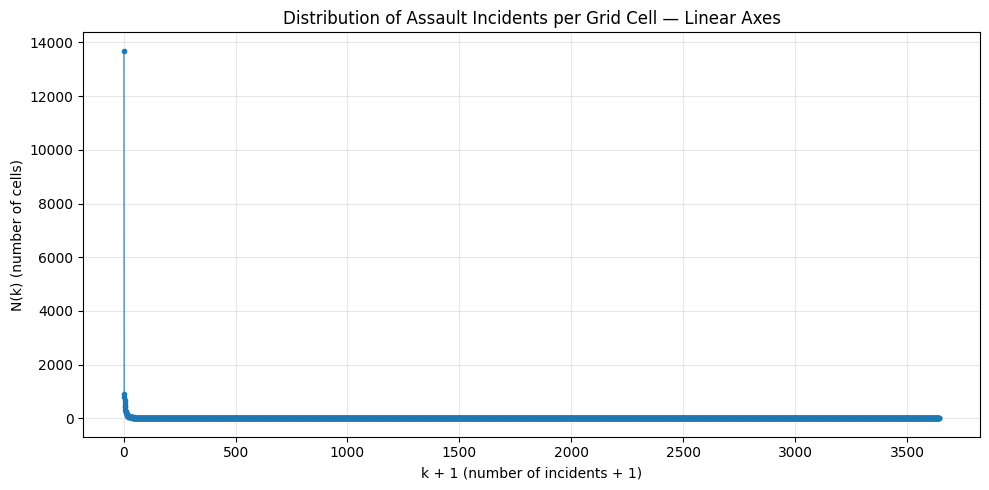

In [3]:
# Step 4: Plot (k+1) vs N(k) on linear axes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values + 1, N_k, 'o-', markersize=3, linewidth=0.8)
ax.set_xlabel('k + 1 (number of incidents + 1)')
ax.set_ylabel('N(k) (number of cells)')
ax.set_title('Distribution of Assault Incidents per Grid Cell — Linear Axes')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 5: Log-log plot

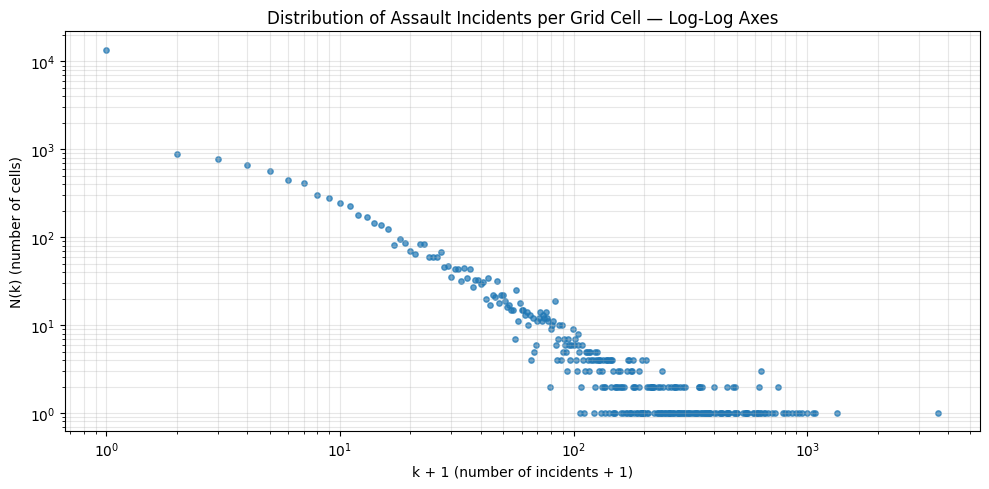

In [4]:
# Step 5: Plot (k+1) vs N(k) on log-log axes
# Filter out k values where N(k) == 0 (can't plot log of 0)
mask = N_k > 0

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(k_values[mask] + 1, N_k[mask], s=15, alpha=0.7)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k + 1 (number of incidents + 1)')
ax.set_ylabel('N(k) (number of cells)')
ax.set_title('Distribution of Assault Incidents per Grid Cell — Log-Log Axes')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### Step 6: Does Assault follow a power-law spatial distribution?

*TODO: Fill in after running the notebook and inspecting the log-log plot.*

<!-- Guiding questions:
- Does the log-log plot show an approximately straight line?
- A straight line on log-log axes means N(k) ~ (k+1)^(-alpha), i.e. a power law.
- Are there deviations at the extremes (very low or very high k)?
-->

### Step 7: Implications of spatial concentration

*TODO: Fill in with your own thinking.*

<!-- Guiding questions:
- If crime is concentrated in a tiny fraction of cells, what does the "average block" crime rate actually tell you?
- How does this affect neighborhood-level statistics, policing strategy, and city planning?
- Is the mean a useful summary statistic for a power-law distribution?
-->

### Partial Conclusion

*TODO: Brief summary of findings from Assignment 1.4.*